Carregando datasets...
Formato do set de treino: (147613, 51)
Formato do set de teste:  (63267, 51)

Processamento e encoding de features...
Features depois do encoding: 64

Treinando classificador binário (XGBoost)
Fazendo fit no modelo...
Predizendo no conjunto de teste...

--- Relatório - Classe Binária ---
              precision    recall  f1-score   support

  Normal (0)       0.74      0.89      0.81     30351
  Ataque (1)       0.87      0.71      0.78     32916

    accuracy                           0.80     63267
   macro avg       0.81      0.80      0.80     63267
weighted avg       0.81      0.80      0.80     63267



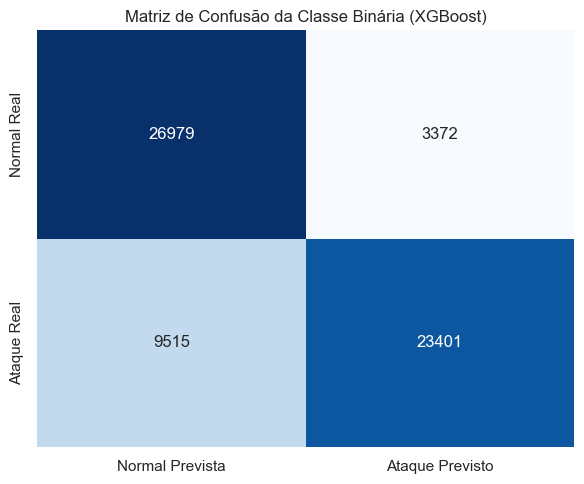


Treinando o Classificador Multi-Classe (XGBoost)
Fazendo fit no modelo...
Predizendo no conjunto de teste...

--- Relatório - Multiclasse ---
                precision    recall  f1-score   support

      Analysis       0.30      0.46      0.36      3990
           DoS       1.00      1.00      1.00     11847
      Exploits       0.36      0.62      0.45      8192
       Fuzzers       0.29      0.65      0.40      4085
        Normal       0.84      0.46      0.60     30351
Reconnaissance       0.79      0.87      0.83      4802

      accuracy                           0.63     63267
     macro avg       0.60      0.68      0.61     63267
  weighted avg       0.73      0.63      0.64     63267



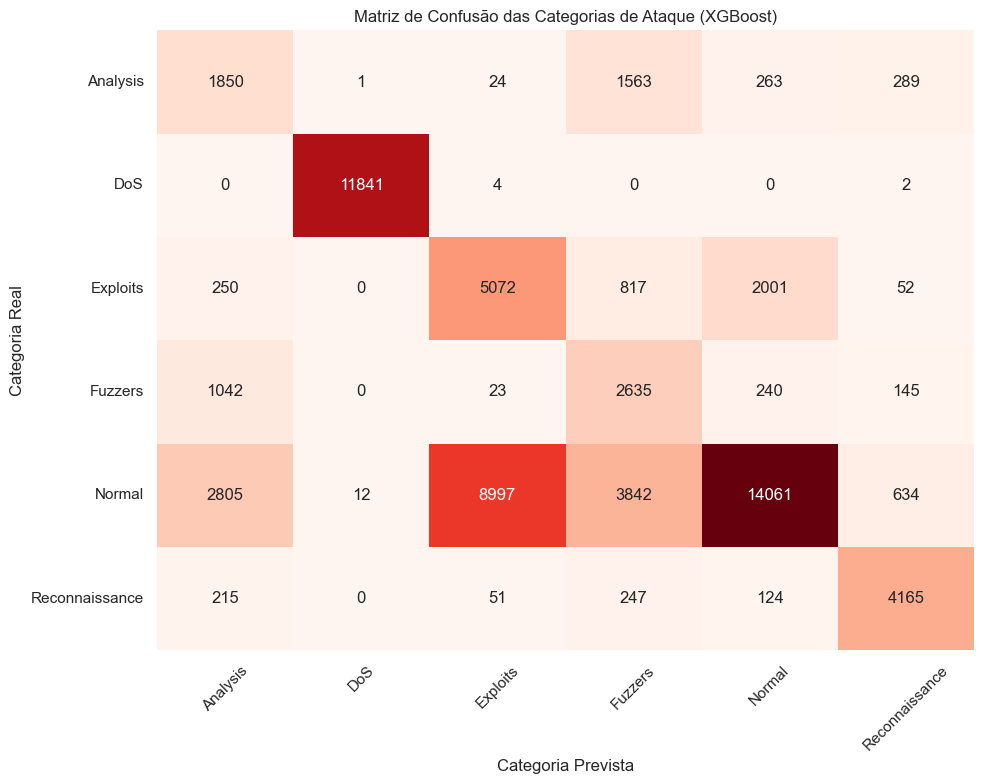


Top 10 Features Mais Importantes (XGBoost)
         Feature  Importancia
ct_dst_sport_ltm     0.210118
       state_CON     0.111301
ct_flw_http_mthd     0.108701
       service_-     0.077585
     trans_depth     0.067435
           spkts     0.063324
      ct_srv_dst     0.057399
      ct_srv_src     0.035445
          synack     0.029353
ct_src_dport_ltm     0.022153


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import shuffle

sns.set_theme(style="whitegrid")

# ==========================================
# 1. CARREGANDO DATASETS
# ==========================================
print("Carregando datasets...")
train_df = pd.read_csv("ubuntu-server_training-set.csv")
test_df = pd.read_csv("ubuntu-server_testing-set.csv")

print(f"Formato do set de treino: {train_df.shape}")
print(f"Formato do set de teste:  {test_df.shape}")

# ==========================================
# 2. PROCESSAMENTO DE DADOS E ENCODING
# ==========================================
print("\nProcessamento e encoding de features...")

# Define alvos e identidades/tempo de rede específicas que o modelo não deve processar
targets = ['label', 'attack_cat']
identities = ['id', 'srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime', 'ct_state_ttl']
drop_cols = targets + identities

# Separa features X e alvos y, ignorando colunas se já estiverem droppadas
X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train_bin = train_df['label']
y_train_multi = train_df['attack_cat']

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test_bin = test_df['label']
y_test_multi = test_df['attack_cat']

# Colunas categóricas para encoding
cat_cols = ['proto', 'service', 'state']

# One-Hot para features categóricas
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)

# Alinha as colunas de treino e teste, o resto preenche com 0 se tiverem faltando no teste
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# NOVO PARA XGBOOST: O target multiclasse não pode ser string. 
# Precisamos converter "Normal", "DoS", etc. para 0, 1, 2...
label_encoder = LabelEncoder()
y_train_multi_encoded = label_encoder.fit_transform(y_train_multi)
# Atenção: Usamos apenas transform() no teste para manter o mapeamento exato do treino
y_test_multi_encoded = label_encoder.transform(y_test_multi)

# Guardar os nomes das classes para os gráficos e relatórios
class_names = label_encoder.classes_

print(f"Features depois do encoding: {X_train_encoded.shape[1]}")

# ==========================================
# 3. CLASSIFICAÇÃO BINÁRIA (Ataque X Normal)
# ==========================================
print("\n" + "="*50)
print("Treinando classificador binário (XGBoost)")
print("="*50)

# Calcular pesos das amostras para lidar com o desbalanceamento
sample_weights_bin = compute_sample_weight(class_weight='balanced', y=y_train_bin)

# Inicia o XGBoost para classificação binária
xgb_bin = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1
)

print("Fazendo fit no modelo...")
xgb_bin.fit(X_train_encoded, y_train_bin, sample_weight=sample_weights_bin)

print("Predizendo no conjunto de teste...")
y_pred_bin = xgb_bin.predict(X_test_encoded)

# Métricas binárias
print("\n--- Relatório - Classe Binária ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Ataque (1)']))

# Matriz de confusão binária
plt.figure(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal Prevista', 'Ataque Previsto'],
            yticklabels=['Normal Real', 'Ataque Real'])
plt.title('Matriz de Confusão da Classe Binária (XGBoost)')
plt.tight_layout()
plt.show()

# ==========================================
# 4. CLASSIFICAÇÃO MULTICLASSE (Classe dos ataques)
# ==========================================
print("\n" + "="*50)
print("Treinando o Classificador Multi-Classe (XGBoost)")
print("="*50)

# Calcular pesos das amostras multiclasse
sample_weights_multi = compute_sample_weight(class_weight='balanced', y=y_train_multi_encoded)

# Inicializar o novo XGBoost para multiclasse
xgb_multi = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax',
    num_class=len(class_names),
    random_state=42,
    n_jobs=-1
)

print("Fazendo fit no modelo...")
xgb_multi.fit(X_train_encoded, y_train_multi_encoded, sample_weight=sample_weights_multi)

print("Predizendo no conjunto de teste...")
y_pred_multi_encoded = xgb_multi.predict(X_test_encoded)

# Reverter os números (0, 1, 2) de volta para strings ("Normal", "DoS") para o relatório
y_pred_multi = label_encoder.inverse_transform(y_pred_multi_encoded)

# Métricas multiclasse
print("\n--- Relatório - Multiclasse ---")
print(classification_report(y_test_multi, y_pred_multi, target_names=class_names))

# Matriz de confusão multiclasse
plt.figure(figsize=(10, 8))
# Passamos os arrays originais (com strings) para que a matriz gere os labels corretamente
cm_multi = confusion_matrix(y_test_multi, y_pred_multi, labels=class_names)

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão das Categorias de Ataque (XGBoost)')
plt.xlabel('Categoria Prevista')
plt.ylabel('Categoria Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 5. IMPORTANCIA DAS FEATURES
# ==========================================
print("\n" + "="*50)
print("Top 10 Features Mais Importantes (XGBoost)")
print("="*50)

feature_importances = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importancia': xgb_multi.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(feature_importances.head(10).to_string(index=False))


Gerando Cenário de Rede Desbalanceado (mais tráfego benigno) para o NIDS
Total de logs na simulação: 30970
Tráfego Normal: 30350 (98.00%)
Tráfego de Ataque: 620 (2.00%)

Filtro de Redução por Limiar de Confiança (Entropia)
Limiar de Incerteza (Tau): 0.8
Volume Original na Simulação: 30970
Logs Retidos (Alertas + Dúvidas): 17765 (57.36%)
Logs Reduzidos (Arquivados/Descartados): 13205 (42.64%)

Log Reduction Rate (LRR): 42.64%

Verificação de Segurança do Filtro
Total de Ataques Reais na Simulação: 620
Ataques Retidos (Sucesso): 567 (91.45%)
Ataques que ESCAPARAM (Falha do Filtro): 53 (8.55%)


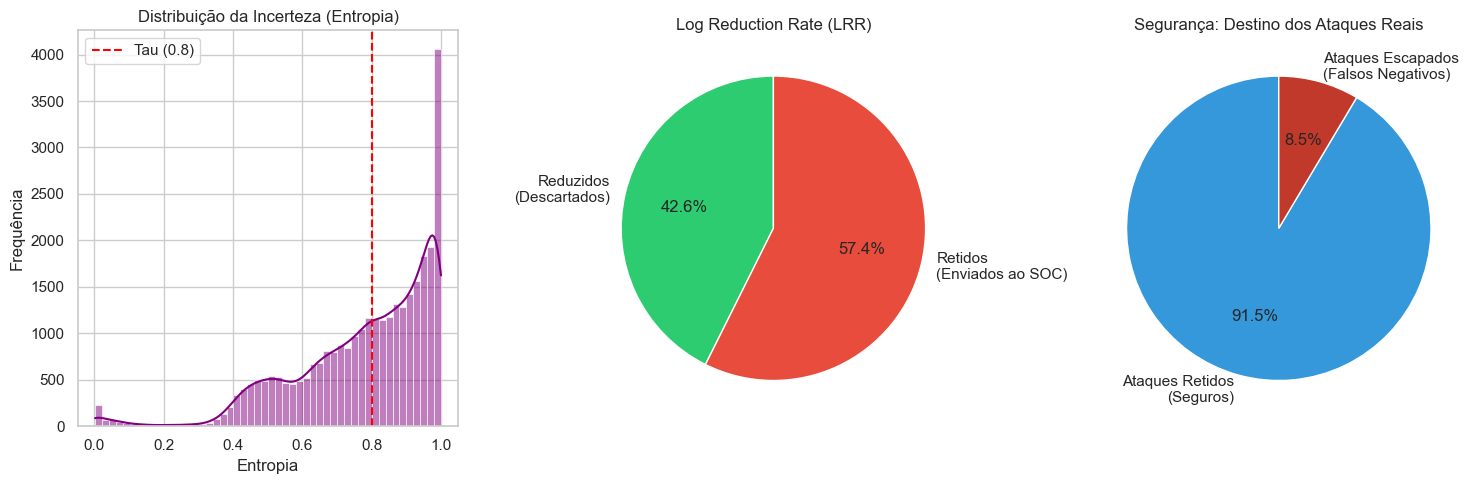


Calculando Curvas de Trade-off (RVL vs ARD) para Otimização


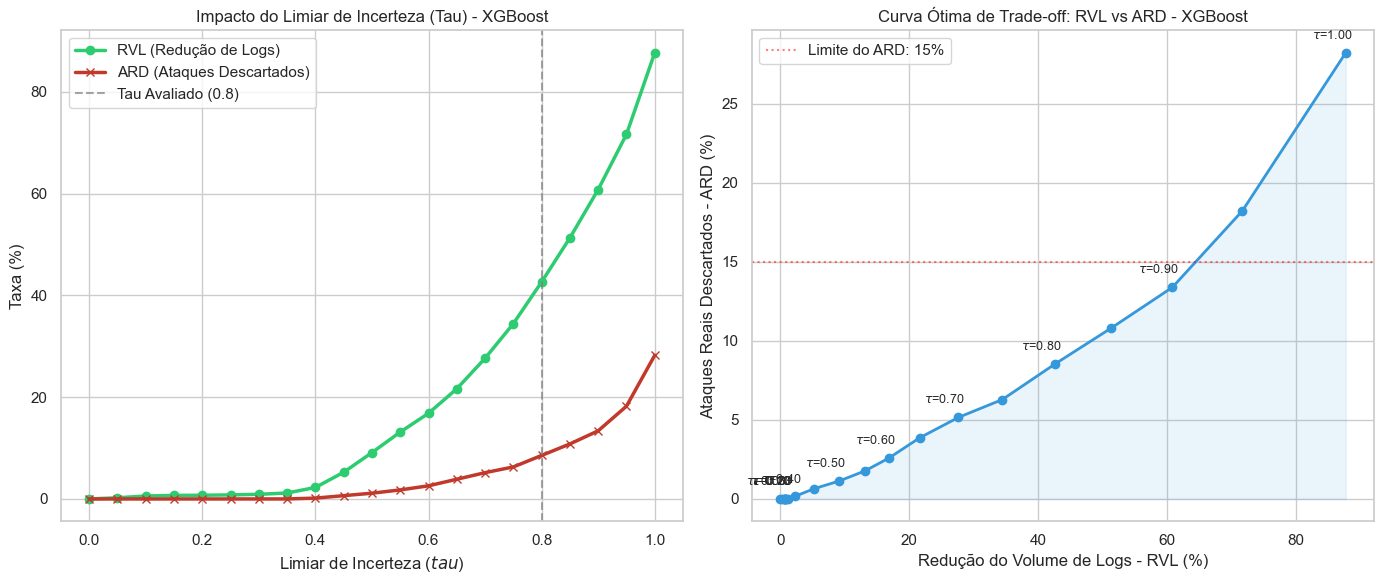

Ponto Ótimo Sugerido (ARD <= 15.0%): Tau = 0.90 | RVL = 60.79% | ARD = 13.39%

Exportando dados de Trade-off (Tau, RVL, ARD) para CSV
Dados exportados com sucesso para: tradeoff_xgb.csv


In [2]:
# ==========================================
# 6. SIMULAÇÃO DE CENÁRIO REALISTA (Desbalanceado)
# ==========================================
print("\n" + "="*50)
print("Gerando Cenário de Rede Desbalanceado (mais tráfego benigno) para o NIDS")
print("="*50)

# Reconstruindo o dataframe de teste temporariamente para facilitar a amostragem
test_analysis_df = X_test_encoded.copy()
test_analysis_df['label'] = y_test_bin

# Separando tráfego normal e de ataque
normal_data = test_analysis_df[test_analysis_df['label'] == 0]
attack_data = test_analysis_df[test_analysis_df['label'] == 1]

# Definindo a proporção desejada para a simulação realista
prop_normal = 0.98
# Define o tamanho total da simulação com base nos dados normais disponíveis para evitar oversampling excessivo
total_sim_logs = int(len(normal_data) / prop_normal) 

# Se o total calculado ultrapassar o tamanho do dataset inteiro, limitamos ao tamanho do test_set original
if total_sim_logs > len(test_analysis_df):
    total_sim_logs = len(test_analysis_df)

n_normal = int(total_sim_logs * prop_normal)
n_attack = total_sim_logs - n_normal

# Amostragem
# Utilizamos replace=True caso o número de ataques requisitado seja maior do que os disponíveis no teste
normal_sample = normal_data.sample(n=n_normal, random_state=42, replace=(n_normal > len(normal_data)))
attack_sample = attack_data.sample(n=n_attack, random_state=42, replace=(n_attack > len(attack_data)))

# Juntando e embaralhando para simular um fluxo de rede contínuo
sim_df = pd.concat([normal_sample, attack_sample])
sim_df = shuffle(sim_df, random_state=42).reset_index(drop=True)

# Separando X (features) e Y (labels reais) do cenário simulado
X_sim = sim_df.drop(columns=['label'])
y_sim_bin = sim_df['label']

print(f"Total de logs na simulação: {len(sim_df)}")
print(f"Tráfego Normal: {len(normal_sample)} ({(len(normal_sample)/len(sim_df))*100:.2f}%)")
print(f"Tráfego de Ataque: {len(attack_sample)} ({(len(attack_sample)/len(sim_df))*100:.2f}%)")

# ==========================================
# 7. FILTRO LOGS BASEADO EM ENTROPIA
# ==========================================
print("\n" + "="*50)
print("Filtro de Redução por Limiar de Confiança (Entropia)")
print("="*50)

# Extrair as probabilidades usando o modelo XGBoost binário já treinado na Célula 1
probs_sim = xgb_bin.predict_proba(X_sim)

# Calcular a Entropia de Shannon (Incerteza)
entropies_sim = scipy.stats.entropy(probs_sim, base=2, axis=1)

# Definir o Limiar de Confiança (Tau)
tau = 0.8

# Condição para reter o log:
# Probabilidade da classe 1 (Ataque) > 50%  OU  Entropia >= tau (Dúvida do modelo)
alert_mask_sim = (probs_sim[:, 1] > 0.5) | (entropies_sim >= tau)

# Máscaras booleanas de retenção e descarte
logs_retained_mask = alert_mask_sim
logs_dropped_mask = ~alert_mask_sim

total_logs_sim = len(y_sim_bin)
logs_retained_count = np.sum(logs_retained_mask)
logs_dropped_count = np.sum(logs_dropped_mask)

# Log Reduction Rate (LRR)
log_reduction_rate = (logs_dropped_count / total_logs_sim) * 100

print(f"Limiar de Incerteza (Tau): {tau}")
print(f"Volume Original na Simulação: {total_logs_sim}")
print(f"Logs Retidos (Alertas + Dúvidas): {logs_retained_count} ({(logs_retained_count/total_logs_sim)*100:.2f}%)")
print(f"Logs Reduzidos (Arquivados/Descartados): {logs_dropped_count} ({(logs_dropped_count/total_logs_sim)*100:.2f}%)\n")
print(f"Log Reduction Rate (LRR): {log_reduction_rate:.2f}%")

# ==========================================
# 8. VERIFICAÇÃO DE SEGURANÇA (False Negatives do Filtro)
# ==========================================
print("\n" + "="*50)
print("Verificação de Segurança do Filtro")
print("="*50)

# Máscara de onde os ataques REAIS estão
real_attacks_mask = (y_sim_bin == 1)
total_real_attacks = np.sum(real_attacks_mask)

# Ataques que foram descartados (Falso Negativo Crítico do pipeline)
escaped_attacks_mask = real_attacks_mask & logs_dropped_mask
escaped_attacks_count = np.sum(escaped_attacks_mask)

# Ataques que foram retidos com sucesso
caught_attacks_count = total_real_attacks - escaped_attacks_count
escape_rate = (escaped_attacks_count / total_real_attacks) * 100 if total_real_attacks > 0 else 0

print(f"Total de Ataques Reais na Simulação: {total_real_attacks}")
print(f"Ataques Retidos (Sucesso): {caught_attacks_count} ({(caught_attacks_count/total_real_attacks)*100:.2f}%)")
print(f"Ataques que ESCAPARAM (Falha do Filtro): {escaped_attacks_count} ({escape_rate:.2f}%)")

# ==========================================
# 9. VISUALIZAÇÕES DE IMPACTO
# ==========================================
plt.figure(figsize=(15, 5))

# Gráfico 1: Distribuição da Entropia
plt.subplot(1, 3, 1)
sns.histplot(entropies_sim, bins=50, kde=True, color='purple')
plt.axvline(x=tau, color='red', linestyle='--', label=f'Tau ({tau})')
plt.title('Distribuição da Incerteza (Entropia)')
plt.xlabel('Entropia')
plt.ylabel('Frequência')
plt.legend()

# Gráfico 2: Eficiência da Redução de Logs
plt.subplot(1, 3, 2)
plt.pie([logs_dropped_count, logs_retained_count], 
        labels=['Reduzidos\n(Descartados)', 'Retidos\n(Enviados ao SOC)'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Log Reduction Rate (LRR)')

# Gráfico 3: Impacto na Segurança
plt.subplot(1, 3, 3)
plt.pie([caught_attacks_count, escaped_attacks_count], 
        labels=['Ataques Retidos\n(Seguros)', 'Ataques Escapados\n(Falsos Negativos)'],
        autopct='%1.1f%%', colors=['#3498db', '#c0392b'], startangle=90)
plt.title('Segurança: Destino dos Ataques Reais')

plt.tight_layout()
plt.show()

# ==========================================
# 10. ANÁLISE DE TRADE-OFF (CURVA DE OTIMIZAÇÃO)
# ==========================================
print("\n" + "="*50)
print("Calculando Curvas de Trade-off (RVL vs ARD) para Otimização")
print("="*50)

# Array com valores de Tau de 0.0 até 1.0 com passos de 0.05
tau_values = np.arange(0.0, 1.05, 0.05)
lrr_list = []
ard_list = []

# Iterando sobre cada possível Tau para calcular as métricas
for t in tau_values:
    # Máscara de alerta para o Tau atual
    current_alert_mask = (probs_sim[:, 1] > 0.5) | (entropies_sim >= t)
    current_dropped_mask = ~current_alert_mask
    
    # Cálculo do RVL (Redução de Logs)
    current_lrr = (np.sum(current_dropped_mask) / total_logs_sim) * 100
    lrr_list.append(current_lrr)
    
    # Cálculo do ARD (Ataques Descartados)
    current_escaped = np.sum(real_attacks_mask & current_dropped_mask)
    current_ard = (current_escaped / total_real_attacks) * 100 if total_real_attacks > 0 else 0
    ard_list.append(current_ard)

# Plotando os Gráficos de Otimização
plt.figure(figsize=(14, 6))

# Gráfico A: Comportamento Dinâmico por Tau
plt.subplot(1, 2, 1)
plt.plot(tau_values, lrr_list, label='RVL (Redução de Logs)', color='#2ecc71', linewidth=2.5, marker='o')
plt.plot(tau_values, ard_list, label='ARD (Ataques Descartados)', color='#c0392b', linewidth=2.5, marker='x')
plt.axvline(x=tau, color='gray', linestyle='--', alpha=0.7, label=f'Tau Avaliado ({tau})')
plt.title('Impacto do Limiar de Incerteza (Tau) - XGBoost')
plt.xlabel('Limiar de Incerteza ($tau$)')
plt.ylabel('Taxa (%)')
plt.legend()

# Gráfico B: Curva de Pareto (Trade-off Direto RVL vs ARD)
plt.subplot(1, 2, 2)
plt.plot(lrr_list, ard_list, color='#3498db', linewidth=2, marker='o', markersize=6)
plt.fill_between(lrr_list, ard_list, color='#3498db', alpha=0.1) # Destaque visual leve

# Anotando os valores de tau nos pontos do gráfico
for i, t in enumerate(tau_values):
    # Condição para anotar apenas se houver mudança significativa ou passos grandes
    if i % 2 == 0 or t == 1.0: 
        plt.annotate(f"$\\tau$={t:.2f}", (lrr_list[i], ard_list[i]), 
                     textcoords="offset points", xytext=(-10,10), ha='center', fontsize=9)

# Linha de aceitabilidade
plt.axhline(y=15.0, color='red', linestyle=':', alpha=0.5, label='Limite do ARD: 15%')

plt.title('Curva Ótima de Trade-off: RVL vs ARD - XGBoost')
plt.xlabel('Redução do Volume de Logs - RVL (%)')
plt.ylabel('Ataques Reais Descartados - ARD (%)')
plt.legend()

plt.tight_layout()
plt.savefig('tradeoff_rvl_ard_xgb.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

# Resumo do Ponto Ótimo Automático
ard_limit = 15.0
valid_indices = [i for i, ard in enumerate(ard_list) if ard <= ard_limit]
if valid_indices:
    best_idx = max(valid_indices, key=lambda i: lrr_list[i]) # Pega o índice com maior RVL dentre os válidos
    best_tau = tau_values[best_idx]
    best_rvl = lrr_list[best_idx]
    best_ard = ard_list[best_idx]
    print(f"Ponto Ótimo Sugerido (ARD <= {ard_limit}%): Tau = {best_tau:.2f} | RVL = {best_rvl:.2f}% | ARD = {best_ard:.2f}%")
else:
    print(f"Não há ponto ótimo que mantenha os ataques descartados abaixo de {ard_limit}%.")

# ==========================================
# 11. EXPORTANDO DADOS PARA PLOTAGEM UNIFICADA
# ==========================================
print("\n" + "="*50)
print("Exportando dados de Trade-off (Tau, RVL, ARD) para CSV")
print("="*50)

# Criando um DataFrame com os dados calculados no bloco 10
tradeoff_df = pd.DataFrame({
    'Tau': tau_values,
    'RVL': lrr_list,
    'ARD': ard_list
})

nome_arquivo_csv = 'tradeoff_xgb.csv'

# Exportando para CSV (sem salvar o índice para manter o arquivo limpo)
tradeoff_df.to_csv(nome_arquivo_csv, index=False)

print(f"Dados exportados com sucesso para: {nome_arquivo_csv}")